In [22]:
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.optimize import minimize
from statsmodels.tsa.stattools import adfuller, kpss, coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen
import warnings
import sys
sys.path.append("../../tools")
import data
warnings.filterwarnings("ignore")

In [ ]:
# ── ETF Universe (same as etf_analysis.ipynb) ────────────────────────────────
# Hardcoded metadata from provider fact sheets — last updated 2026-04-09
ETF_META = {
    "VTIP": {"name": "Vanguard Short-Term Inflation Protected Securities",  "mod_duration": 0.10, "convexity": 0.00, "expense_ratio": 0.1356},
    "SHY":  {"name": "iShares 1-3 Year Treasury",                           "mod_duration": 1.83, "convexity": 0.05, "expense_ratio": 0.15},
    "IEI":  {"name": "iShares 3-7 Year Treasury",                           "mod_duration": 4.38, "convexity": 0.24, "expense_ratio": 0.15},
    "IEF":  {"name": "iShares 7-10 Year Treasury",                          "mod_duration": 7.48, "convexity": 0.69, "expense_ratio": 0.15},
    "TLH":  {"name": "iShares 10-20 Year Treasury",                         "mod_duration": 11.73,"convexity": 1.65, "expense_ratio": 0.15},
    "TLT":  {"name": "iShares 20+ Year Treasury",                           "mod_duration": 15.97,"convexity": 3.40, "expense_ratio": 0.15},
    "VGIT": {"name": "Vanguard Intermediate Treasury",                      "mod_duration": 5.30, "convexity": 0.38, "expense_ratio": 0.04},
    "VGLT": {"name": "Vanguard Long-Term Treasury",                         "mod_duration": 13.72,"convexity": 2.44, "expense_ratio": 0.04},
    "TIP":  {"name": "iShares TIPS Bond",                                   "mod_duration": 6.84, "convexity": 0.61, "expense_ratio": 0.19},
    "AGG":  {"name": "iShares US Aggregate (benchmark)",                    "mod_duration": 6.04, "convexity": 0.54, "expense_ratio": 0.03},
}

TICKERS = list(ETF_META.keys())
BENCH   = "AGG"

# ── Data Load ─────────────────────────────────────────────────────────────────
raw = {}
for tk in TICKERS:
    hist = yf.Ticker(tk).history(period="max")  # full history for stationarity/cointegration
    hist.index = hist.index.tz_localize(None)
    raw[tk] = hist
    print(f"{tk}: {len(hist)} rows  {hist.index[0].date()} → {hist.index[-1].date()}")

prices = pd.DataFrame({tk: raw[tk]["Close"] for tk in TICKERS}).dropna(how="all")
print(f"\nPrice matrix: {prices.shape}  ({prices.dropna().shape[0]} complete rows)")

VTIP: 3389 rows  2012-10-16 → 2026-04-10
SHY: 5963 rows  2002-07-30 → 2026-04-10
IEI: 4842 rows  2007-01-11 → 2026-04-10
IEF: 5963 rows  2002-07-30 → 2026-04-10
TLH: 4842 rows  2007-01-11 → 2026-04-10
TLT: 5963 rows  2002-07-30 → 2026-04-10
VGIT: 4119 rows  2009-11-23 → 2026-04-10
VGLT: 4092 rows  2010-01-04 → 2026-04-10
TIP: 5621 rows  2003-12-05 → 2026-04-10
AGG: 5669 rows  2003-09-29 → 2026-04-10

Price matrix: (5963, 10)  (3389 complete rows)


In [24]:
# ── Total Return Series (price + dividends) ───────────────────────────────────
# yfinance `history()` with auto_adjust=True adjusts prices for dividends,
# so pct_change() on Close gives total return.
# For cumulative total return, we compound those daily returns.

daily_ret = prices.pct_change().dropna()
cum_ret   = (1 + daily_ret).cumprod()

# Also compute log returns for stationarity tests
log_prices = np.log(prices.dropna())
log_ret    = log_prices.diff().dropna()

print("Daily returns shape:", daily_ret.shape)
print("\nAnnualized return (full history):")
for tk in TICKERS:
    n   = len(daily_ret[tk].dropna())
    ann = (1 + daily_ret[tk].dropna()).prod() ** (252/n) - 1
    print(f"  {tk:5s}: {ann*100:+.2f}%")

Daily returns shape: (3388, 10)

Annualized return (full history):
  VTIP : +2.23%
  SHY  : +1.38%
  IEI  : +1.45%
  IEF  : +1.25%
  TLH  : +0.39%
  TLT  : +0.19%
  VGIT : +1.47%
  VGLT : +0.58%
  TIP  : +1.73%
  AGG  : +1.82%


# Treasury ETF Efficient Frontier

This notebook builds out the quantitative backbone for ETF selection:  
stationarity, cointegration, risk/return statistics, and two variants of the efficient frontier.

**Two frontier variants:**
1. **Historical returns** — uses realized total returns. Reflects the actual rate cycle; the 2022 bond crash dominates.
2. **YTM-based expected returns** — uses current dividend yield as the forward expected return at each ETF's duration horizon. Theoretically sounder for bonds: yield ≈ expected return if held to duration.

Comparing both reveals how sensitive allocation is to the return assumption — a key model risk in fixed income optimization.

## 1. Stationarity Tests

Before running any regression or cointegration test, confirm the order of integration.

**Expected result:**
- Price **levels** are I(1) — non-stationary, contain a unit root (ADF fails to reject, KPSS rejects)
- Log-returns are I(0) — stationary (ADF rejects unit root, KPSS fails to reject)

If prices are I(1), cointegration tests are valid. If returns are I(0), the covariance matrix is well-defined.

In [25]:
def run_adf(series, maxlag=5):
    s = series.dropna()
    result = adfuller(s, maxlag=maxlag, autolag="AIC")
    return {"ADF stat": round(result[0], 4), "p-value": round(result[1], 4),
            "Reject H0 (unit root)": result[1] < 0.05}

def run_kpss(series):
    s = series.dropna()
    stat, p, _, _ = kpss(s, regression="c", nlags="auto")
    return {"KPSS stat": round(stat, 4), "p-value": round(p, 4),
            "Reject H0 (stationary)": p < 0.05}

print("=" * 70)
print("PRICE LEVELS — expect: ADF fail to reject, KPSS reject")
print("=" * 70)
for tk in TICKERS:
    adf = run_adf(log_prices[tk])
    kps = run_kpss(log_prices[tk])
    print(f"{tk:5s}  ADF p={adf['p-value']:.3f} ({'' if adf['Reject H0 (unit root)'] else 'NOT '}stationary)  "
          f"KPSS p={kps['p-value']:.3f} ({'NOT ' if not kps['Reject H0 (stationary)'] else ''}stationary)")

print()
print("=" * 70)
print("LOG RETURNS — expect: ADF reject unit root, KPSS fail to reject")
print("=" * 70)
for tk in TICKERS:
    adf = run_adf(log_ret[tk])
    kps = run_kpss(log_ret[tk])
    print(f"{tk:5s}  ADF p={adf['p-value']:.3f} ({'' if adf['Reject H0 (unit root)'] else 'NOT '}stationary)  "
          f"KPSS p={kps['p-value']:.3f} ({'NOT ' if not kps['Reject H0 (stationary)'] else ''}stationary)")

PRICE LEVELS — expect: ADF fail to reject, KPSS reject
VTIP   ADF p=0.998 (NOT stationary)  KPSS p=0.010 (stationary)
SHY    ADF p=0.999 (NOT stationary)  KPSS p=0.010 (stationary)
IEI    ADF p=0.831 (NOT stationary)  KPSS p=0.010 (stationary)
IEF    ADF p=0.523 (NOT stationary)  KPSS p=0.010 (stationary)
TLH    ADF p=0.472 (NOT stationary)  KPSS p=0.010 (stationary)
TLT    ADF p=0.526 (NOT stationary)  KPSS p=0.010 (stationary)
VGIT   ADF p=0.772 (NOT stationary)  KPSS p=0.010 (stationary)
VGLT   ADF p=0.488 (NOT stationary)  KPSS p=0.010 (stationary)
TIP    ADF p=0.894 (NOT stationary)  KPSS p=0.010 (stationary)
AGG    ADF p=0.720 (NOT stationary)  KPSS p=0.010 (stationary)

LOG RETURNS — expect: ADF reject unit root, KPSS fail to reject
VTIP   ADF p=0.000 (stationary)  KPSS p=0.015 (stationary)
SHY    ADF p=0.000 (stationary)  KPSS p=0.013 (stationary)
IEI    ADF p=0.000 (stationary)  KPSS p=0.100 (NOT stationary)
IEF    ADF p=0.000 (stationary)  KPSS p=0.100 (NOT stationary)
TLH   

## 2. Cointegration Tests

If two I(1) series share a common stochastic trend, they're cointegrated — their spread is stationary even though each individually is not.  
For Treasury ETFs, cointegration is likely: they're all driven by the same underlying rate level.

**Why this matters for the efficient frontier:**  
Cointegrated pairs have a long-run equilibrium relationship. Their spread can be modeled and traded (pairs trading).  
But for the efficient frontier, cointegration means **the diversification benefit of mixing similar ETFs is limited** —  
the frontier will overstate benefit of combining, say, IEF and VGIT if they're cointegrated.

**Tests run:**
- **Engle-Granger** (pairwise): simple, directional
- **Johansen** (multivariate): finds number of cointegrating vectors across the full ETF set

=== Pairwise Engle-Granger Cointegration (p < 0.05 = cointegrated) ===
         VTIP    SHY    IEI    IEF    TLH    TLT   VGIT   VGLT    TIP    AGG
VTIP        — 0.793  0.962  0.994  1.000  1.000  0.973  1.000  0.922  0.983 
SHY    0.796       — 0.984  1.000  1.000  1.000  0.988  1.000  0.868  0.989 
IEI    0.745  0.839       — 0.988  1.000  1.000  0.851  1.000  0.512  0.045*
IEF    0.718  0.811  0.922       — 1.000  1.000  0.958  1.000  0.739  0.667 
TLH    0.666  0.785  0.948  0.987       — 0.661  0.963  0.552  0.805  0.944 
TLT    0.735  0.835  0.970  0.994  0.711       — 0.980  1.000  0.878  0.971 
VGIT   0.733  0.832  0.816  0.990  1.000  1.000       — 1.000  0.514  0.045*
VGLT   0.727  0.832  0.967  0.993  0.551  1.000  0.978       — 0.864  0.965 
TIP    0.772  0.679  0.721  0.975  0.994  0.994  0.793  1.000       — 0.787 
AGG    0.708  0.847  0.094  0.874  1.000  1.000  0.041* 1.000  0.512       —


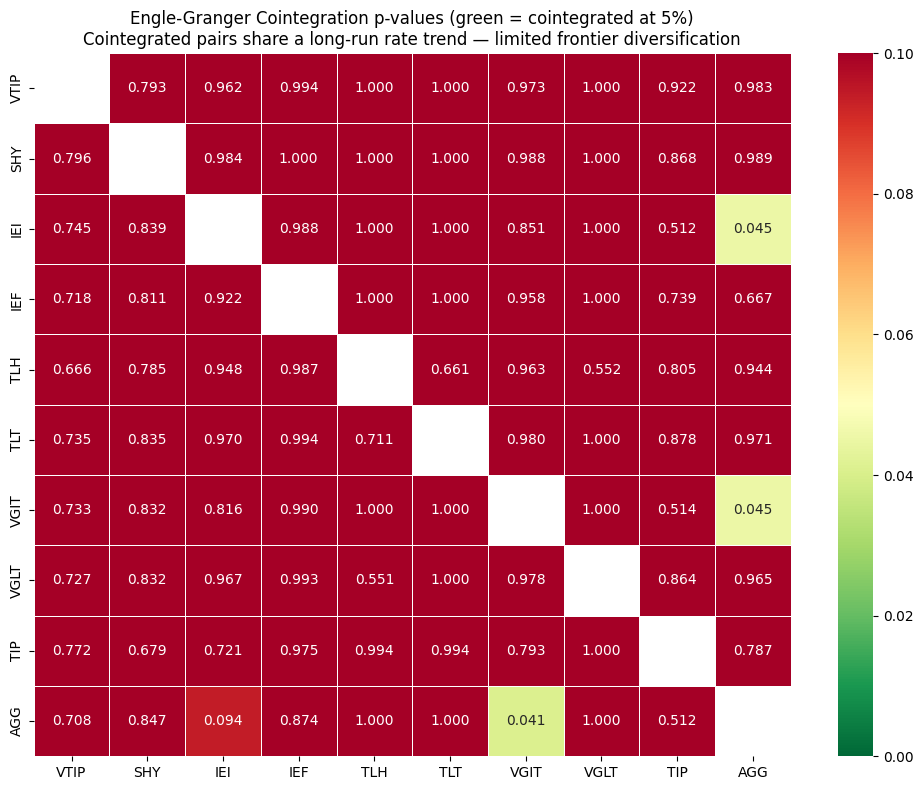

In [26]:
# Use longest common history for cointegration
common_prices = log_prices.dropna()

# ── Pairwise Engle-Granger ────────────────────────────────────────────────────
print("=== Pairwise Engle-Granger Cointegration (p < 0.05 = cointegrated) ===")
print(f"{'':6}", end="")
for tk in TICKERS:
    print(f"{tk:>7}", end="")
print()

coint_matrix = pd.DataFrame(index=TICKERS, columns=TICKERS, dtype=float)
for tk1 in TICKERS:
    print(f"{tk1:5s} ", end="")
    for tk2 in TICKERS:
        if tk1 == tk2:
            coint_matrix.loc[tk1, tk2] = np.nan
            print(f"{'—':>7}", end="")
        else:
            try:
                s1 = common_prices[tk1]
                s2 = common_prices[tk2]
                common = s1.index.intersection(s2.index)
                _, pval, _ = coint(s1[common], s2[common])
                coint_matrix.loc[tk1, tk2] = round(pval, 3)
                marker = "*" if pval < 0.05 else " "
                print(f"{pval:>6.3f}{marker}", end="")
            except Exception:
                coint_matrix.loc[tk1, tk2] = np.nan
                print(f"{'err':>7}", end="")
    print()

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
mask = coint_matrix.isnull()
sns.heatmap(coint_matrix.astype(float), annot=True, fmt=".3f", cmap="RdYlGn_r",
            vmin=0, vmax=0.1, mask=mask, ax=ax, linewidths=0.5)
ax.set_title("Engle-Granger Cointegration p-values (green = cointegrated at 5%)\n"
             "Cointegrated pairs share a long-run rate trend — limited frontier diversification")
plt.tight_layout()
plt.show()

In [27]:
# ── Johansen Multivariate Cointegration ──────────────────────────────────────
# Tests how many cointegrating relationships exist across the full ETF set
jp = common_prices[TICKERS].dropna()
result = coint_johansen(jp, det_order=0, k_ar_diff=1)

print("=== Johansen Test — Trace Statistic ===")
print(f"{'r ≤':<6} {'Trace Stat':>12} {'CV 5%':>10} {'CV 1%':>10} {'Reject?':>10}")
print("-" * 55)
for i in range(min(len(result.lr1), len(TICKERS))):
    trace  = result.lr1[i]
    cv5    = result.cvt[i, 1]
    cv1    = result.cvt[i, 0]
    reject = trace > cv5
    print(f"{i:<6} {trace:>12.3f} {cv5:>10.3f} {cv1:>10.3f} {'YES' if reject else 'no':>10}")

n_coint = sum(result.lr1 > result.cvt[:, 1])
print(f"\nNumber of cointegrating vectors at 5%: {n_coint}")
print(f"Interpretation: {n_coint} common stochastic trends bind the ETF set.")
print("If n_coint > 0: ETFs share long-run rate dynamics — diversification is limited.")

=== Johansen Test — Trace Statistic ===
r ≤      Trace Stat      CV 5%      CV 1%    Reject?
-------------------------------------------------------
0           561.707    239.247    232.103        YES
1           350.631    197.377    190.871        YES
2           213.928    159.529    153.634        YES
3           155.564    125.618    120.367        YES
4           111.306     95.754     91.109        YES
5            74.912     69.819     65.820        YES
6            45.868     47.855     44.493         no
7            20.850     29.796     27.067         no
8            10.573     15.494     13.429         no
9             2.601      3.841      2.705         no

Number of cointegrating vectors at 5%: 6
Interpretation: 6 common stochastic trends bind the ETF set.
If n_coint > 0: ETFs share long-run rate dynamics — diversification is limited.


## 3. Return and Risk Statistics

Summary statistics using full available history and 5-year rolling windows.  
Note: the 2022 rate shock (fastest Fed tightening since 1980) will significantly drag historical returns  
for long-duration ETFs — keep this in mind when interpreting the historical frontier.

=== 5-Year Risk/Return Statistics ===
        Ann Return %  Ann Vol %  Sharpe  Max Drawdown %  CVaR 5% %  Skewness  Kurtosis  Div Yield %  Mod Duration
Ticker                                                                                                           
VTIP            3.56       2.78   1.280           -5.50     -0.395     0.087     3.659         3.61          0.10
SHY             1.73       1.97   0.878           -5.71     -0.268     0.619     5.845         3.72          1.83
IEI             0.53       4.75   0.112          -13.88     -0.646     0.289     1.919         3.57          4.38
IEF            -0.68       7.68  -0.088          -21.40     -1.026     0.164     1.168         3.84          7.48
TLH            -3.31      12.67  -0.261          -35.41     -1.720     0.056     0.607         4.36         11.73
TLT            -5.74      15.85  -0.362          -43.70     -2.152     0.024     0.480         4.52         15.97
VGIT            0.38       5.35   0.071          -

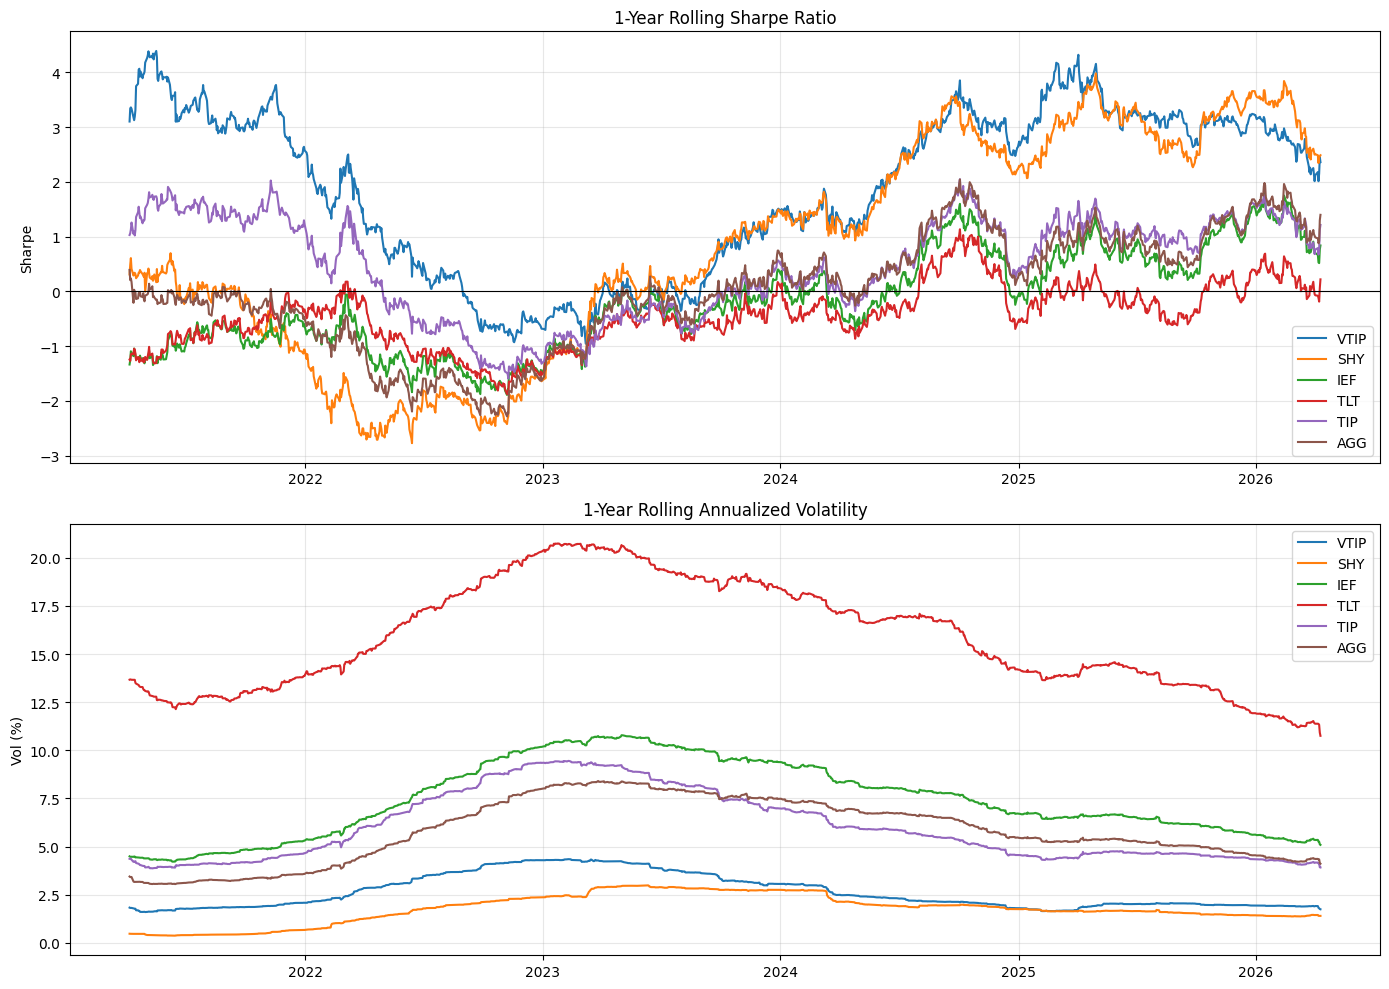

In [28]:
# Use 5Y window for most stats to avoid small-sample issues
ret_5y = daily_ret.tail(5 * 252)

stats = []
for tk in TICKERS:
    r = ret_5y[tk].dropna()
    ann_ret  = (1 + r).prod() ** (252/len(r)) - 1
    ann_vol  = r.std() * np.sqrt(252)
    sharpe   = ann_ret / ann_vol if ann_vol > 0 else np.nan
    
    p = prices[tk].dropna().tail(5*252+1)
    roll_max = p.cummax()
    max_dd   = ((p / roll_max) - 1).min()
    
    skew = r.skew()
    kurt = r.kurtosis()
    
    # CVaR 5% (average loss in worst 5% of days)
    cvar_5 = r[r <= r.quantile(0.05)].mean()
    
    div_ttm   = raw[tk]["Dividends"].tail(252).sum()
    div_yield = div_ttm / raw[tk]["Close"].iloc[-1] * 100
    
    stats.append({
        "Ticker": tk,
        "Ann Return %":  round(ann_ret*100, 2),
        "Ann Vol %":     round(ann_vol*100, 2),
        "Sharpe":        round(sharpe, 3),
        "Max Drawdown %":round(max_dd*100, 2),
        "CVaR 5% %":     round(cvar_5*100, 3),
        "Skewness":      round(skew, 3),
        "Kurtosis":      round(kurt, 3),
        "Div Yield %":   round(div_yield, 2),
        "Mod Duration":  ETF_META[tk]["mod_duration"],
    })

df_stats = pd.DataFrame(stats).set_index("Ticker")
print("=== 5-Year Risk/Return Statistics ===")
print(df_stats.to_string())

# Rolling Sharpe (1Y window)
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

roll_ann_ret = daily_ret.rolling(252).apply(lambda x: (1+x).prod()**(252/252) - 1, raw=False)
roll_vol_252 = daily_ret.rolling(252).std() * np.sqrt(252)
roll_sharpe  = roll_ann_ret / roll_vol_252

plot_tks = ["VTIP", "SHY", "IEF", "TLT", "TIP", "AGG"]
for tk in plot_tks:
    axes[0].plot(roll_sharpe.index[-1260:], roll_sharpe[tk].iloc[-1260:], linewidth=1.5, label=tk)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("1-Year Rolling Sharpe Ratio")
axes[0].set_ylabel("Sharpe")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for tk in plot_tks:
    axes[1].plot(roll_vol_252.index[-1260:], roll_vol_252[tk].iloc[-1260:]*100, linewidth=1.5, label=tk)
axes[1].set_title("1-Year Rolling Annualized Volatility")
axes[1].set_ylabel("Vol (%)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Duration and Convexity

**Modified duration** measures linear price sensitivity: a 1% yield rise → price falls ~duration%.  
**Convexity** is the second-order correction — it means the actual price fall is *less* than duration predicts  
for large rate moves (positive convexity is good for the holder).  

Convexity matters most for large rate shocks and for the long end (TLT has ~3.4 convexity vs IEF's 0.69).  
This is why long-duration ETFs rally *more* than duration predicts in a rally, and fall *less* in a selloff.

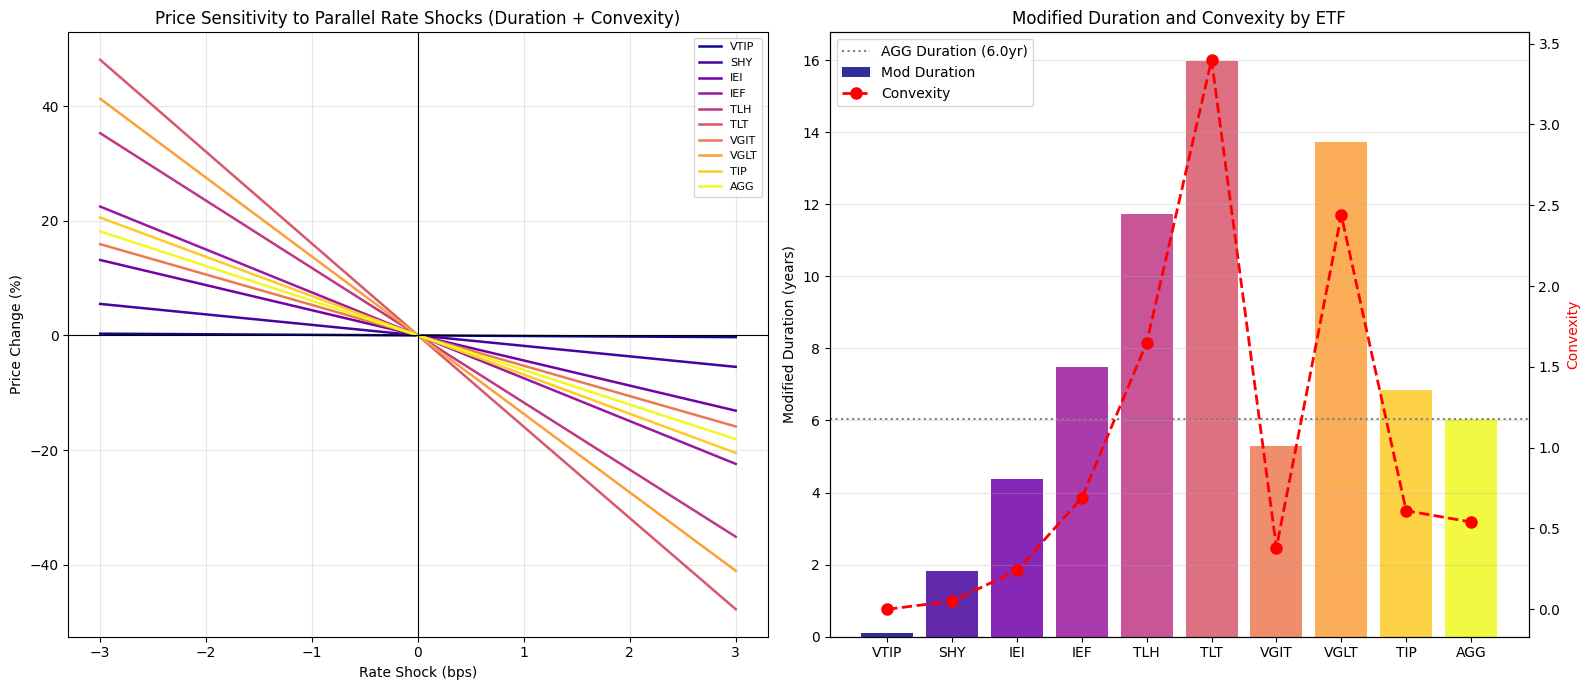


=== Duration and Convexity Table ===
ETF    Name                                     Dur   Convex    Exp%
----------------------------------------------------------------------
VTIP   Vanguard Short-Term Inflation Protected Securities     0.10     0.00  0.1356
SHY    iShares 1-3 Year Treasury               1.83     0.05  0.1500
IEI    iShares 3-7 Year Treasury               4.38     0.24  0.1500
IEF    iShares 7-10 Year Treasury              7.48     0.69  0.1500
TLH    iShares 10-20 Year Treasury            11.73     1.65  0.1500
TLT    iShares 20+ Year Treasury              15.97     3.40  0.1500
VGIT   Vanguard Intermediate Treasury          5.30     0.38  0.0400
VGLT   Vanguard Long-Term Treasury            13.72     2.44  0.0400
TIP    iShares TIPS Bond                       6.84     0.61  0.1900
AGG    iShares US Aggregate (benchmark)        6.04     0.54  0.0300


In [29]:
# Price sensitivity curves for each ETF
rate_shocks = np.linspace(-3.0, 3.0, 300)  # -300bps to +300bps

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors_map = cm.get_cmap("plasma", len(TICKERS))
for i, tk in enumerate(TICKERS):
    d = ETF_META[tk]["mod_duration"]
    c = ETF_META[tk]["convexity"]
    # dP/P ≈ -D*dy + 0.5*C*(dy)^2
    price_chg = (-d * rate_shocks/100 + 0.5 * c * (rate_shocks/100)**2) * 100
    axes[0].plot(rate_shocks, price_chg, linewidth=1.8, label=tk, color=colors_map(i))

axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Price Sensitivity to Parallel Rate Shocks (Duration + Convexity)")
axes[0].set_xlabel("Rate Shock (bps)")
axes[0].set_ylabel("Price Change (%)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Duration ladder
dur_vals  = [ETF_META[tk]["mod_duration"] for tk in TICKERS]
conv_vals = [ETF_META[tk]["convexity"]    for tk in TICKERS]
x = np.arange(len(TICKERS))
bars = axes[1].bar(x, dur_vals, color=[colors_map(i) for i in range(len(TICKERS))], alpha=0.85, label="Mod Duration")
ax1b = axes[1].twinx()
ax1b.plot(x, conv_vals, "o--", color="red", linewidth=2, markersize=8, label="Convexity")
axes[1].set_xticks(x)
axes[1].set_xticklabels(TICKERS)
axes[1].set_title("Modified Duration and Convexity by ETF")
axes[1].set_ylabel("Modified Duration (years)")
ax1b.set_ylabel("Convexity", color="red")
axes[1].axhline(ETF_META[BENCH]["mod_duration"], color="gray", linestyle=":", linewidth=1.5, label=f"AGG Duration ({ETF_META[BENCH]['mod_duration']:.1f}yr)")
lines1, labs1 = axes[1].get_legend_handles_labels()
lines2, labs2 = ax1b.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labs1 + labs2, loc="upper left")
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print("\n=== Duration and Convexity Table ===")
print(f"{'ETF':<6} {'Name':<35} {'Dur':>8} {'Convex':>8} {'Exp%':>7}")
print("-" * 70)
for tk in TICKERS:
    m = ETF_META[tk]
    print(f"{tk:<6} {m['name']:<35} {m['mod_duration']:>8.2f} {m['convexity']:>8.2f} {m['expense_ratio']:>7.4f}")

## 5. Correlation and Rolling Correlation

Treasury ETFs are highly correlated — they all move with interest rates.  
**Key questions:**
- How does correlation change in stress periods (2022 rate shock, COVID flight-to-quality)?
- Does TIP (TIPS) provide any diversification vs. nominal Treasury ETFs?
- How does each ETF correlate with AGG over time?

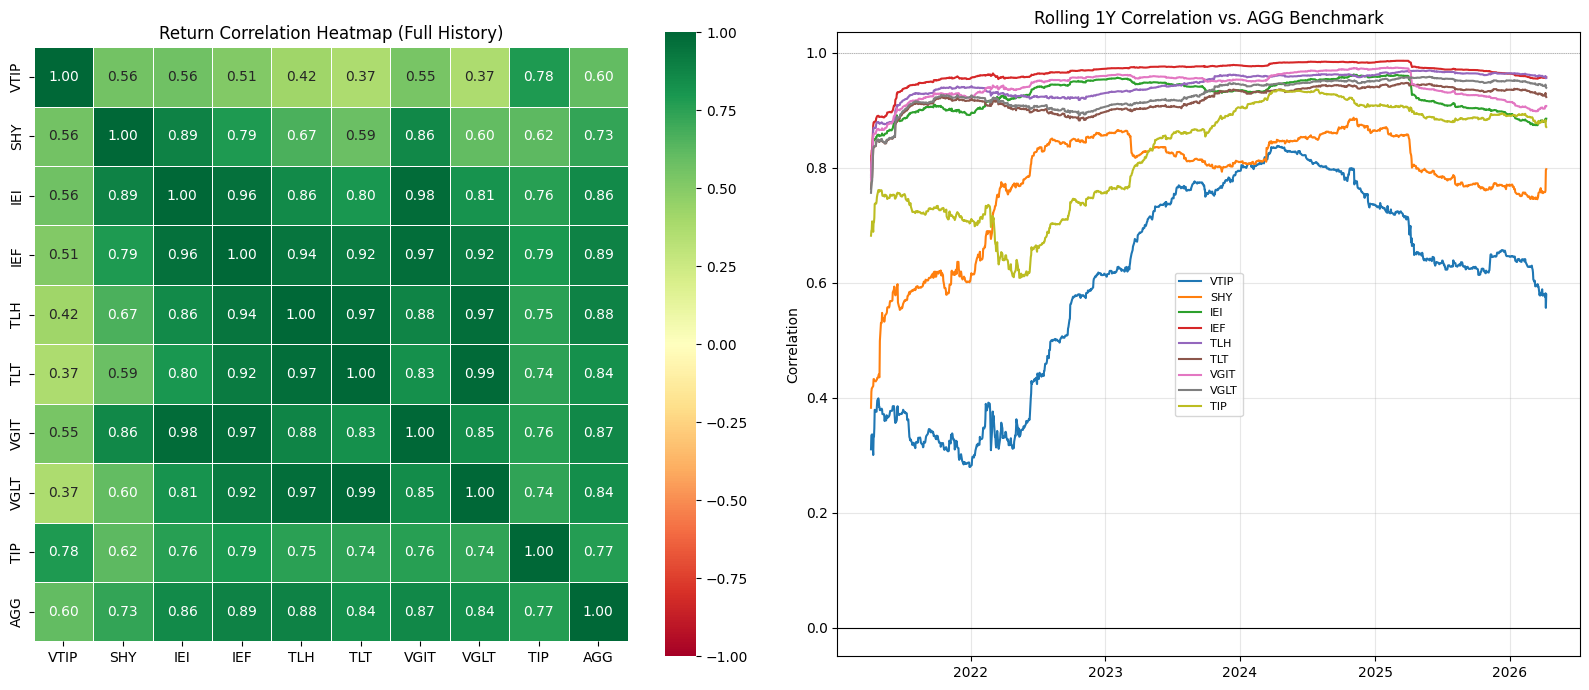


=== Correlation to AGG (full history) ===
  VTIP : +0.602
  SHY  : +0.731
  IEI  : +0.857
  IEF  : +0.886
  TLH  : +0.883
  TLT  : +0.835
  VGIT : +0.866
  VGLT : +0.843
  TIP  : +0.766


In [30]:
ret_common = daily_ret.dropna()
corr = ret_common.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", vmin=-1, vmax=1,
            ax=axes[0], linewidths=0.5, square=True)
axes[0].set_title("Return Correlation Heatmap (Full History)")

# Rolling 1Y correlation to AGG
for tk in [t for t in TICKERS if t != BENCH]:
    roll_corr = ret_common[tk].rolling(252).corr(ret_common[BENCH])
    axes[1].plot(roll_corr.index[-1260:], roll_corr.iloc[-1260:], linewidth=1.5, label=tk)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].axhline(1, color="gray",  linewidth=0.5, linestyle=":")
axes[1].set_title("Rolling 1Y Correlation vs. AGG Benchmark")
axes[1].set_ylabel("Correlation")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== Correlation to AGG (full history) ===")
for tk in [t for t in TICKERS if t != BENCH]:
    print(f"  {tk:5s}: {corr.loc[tk, BENCH]:+.3f}")

## 6. Efficient Frontier — Two Variants

### Variant A: Historical Returns
Uses annualized total returns from yfinance price history.  
**Caveat:** The 2022 rate shock was the worst year for bonds in ~40 years. Long-duration ETFs (TLT, VGLT) show deeply negative realized returns over 5Y history. The historical frontier will heavily favor short-duration ETFs.

### Variant B: YTM-Based Expected Returns
Uses current trailing dividend yield as the proxy for forward expected return.  
This is the theoretically correct approach for bonds: at duration horizon, yield ≈ expected total return  
(assuming no default and you reinvest coupons at current yields).  
The YTM frontier will show a more "normal" tradeoff where long-duration ETFs offer higher expected return for higher risk.

**What changes between them shows you how much your allocation depends on whether you believe history or the yield curve.**

Building frontier (this may take a moment)...
Frontier A (historical): 10 points
Frontier B (YTM-based):  10 points


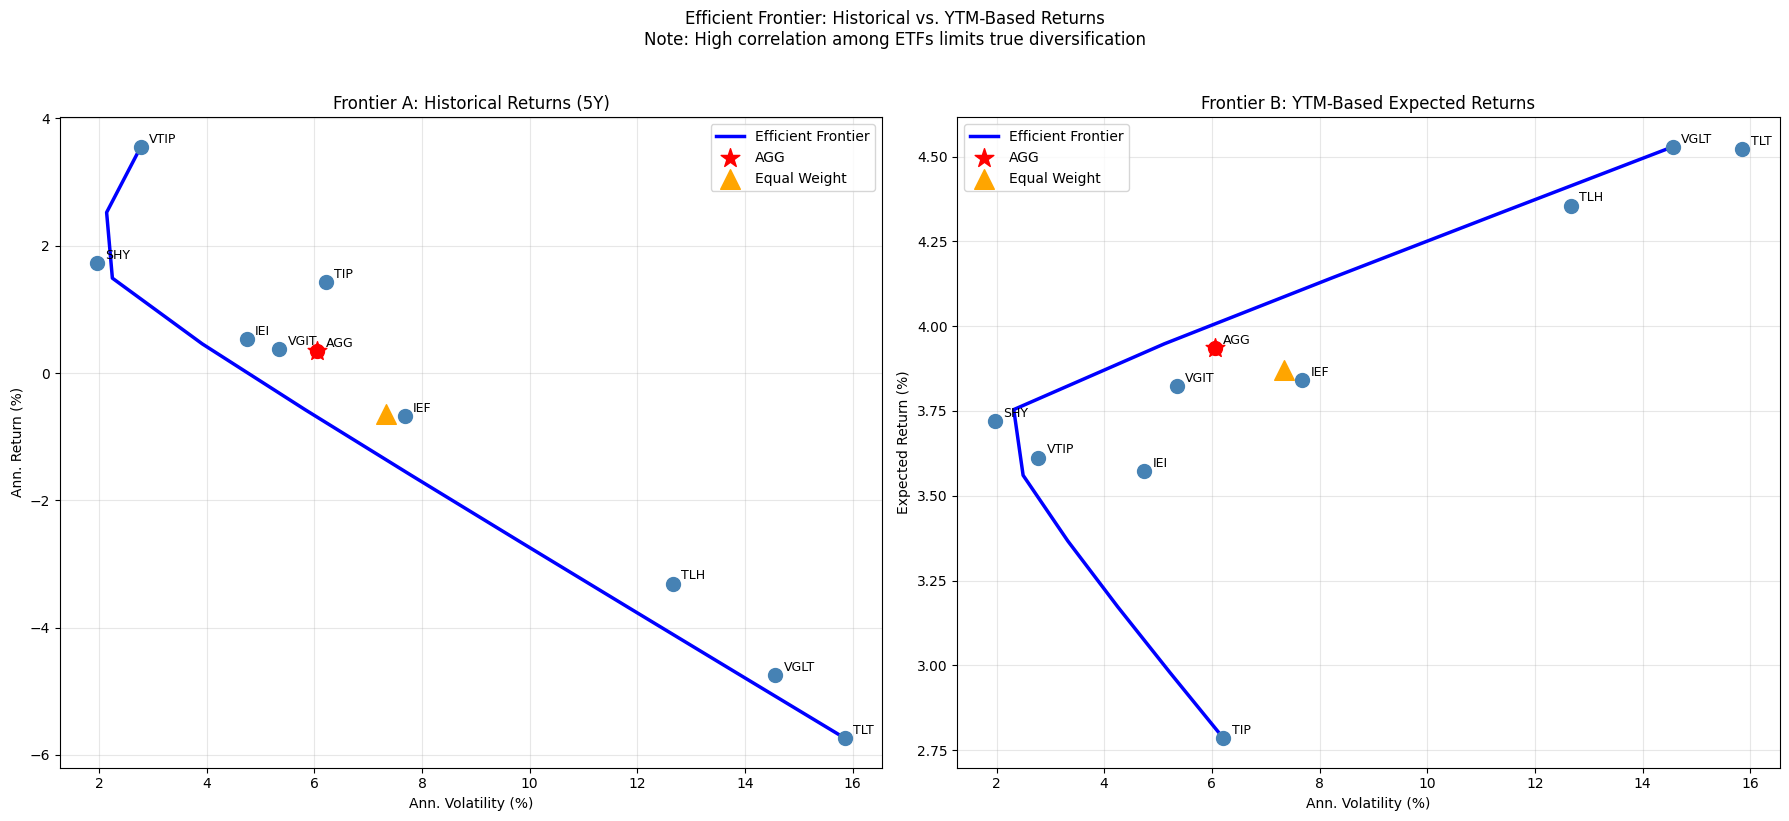

In [31]:
# ── Shared inputs ─────────────────────────────────────────────────────────────
ret_5y    = daily_ret.tail(5*252).dropna(axis=1, how="all")
etf_list  = [tk for tk in TICKERS if tk in ret_5y.columns]
n         = len(etf_list)
cov_mat   = ret_5y[etf_list].cov() * 252  # annualized covariance matrix

# Variant A: historical annualized returns (5Y)
mu_hist = np.array([
    (1 + ret_5y[tk].dropna()).prod() ** (252/len(ret_5y[tk].dropna())) - 1
    for tk in etf_list
])

# Variant B: YTM-based (trailing 12M dividend yield as forward expected return)
mu_ytm = np.array([
    raw[tk]["Dividends"].tail(252).sum() / raw[tk]["Close"].iloc[-1]
    for tk in etf_list
])

def portfolio_stats(weights, mu, cov):
    ret = weights @ mu
    vol = np.sqrt(weights @ cov @ weights)
    return ret, vol

def min_vol_for_target(target_ret, mu, cov, n):
    constraints = [
        {"type": "eq", "fun": lambda w: np.sum(w) - 1},
        {"type": "eq", "fun": lambda w: w @ mu - target_ret},
    ]
    bounds = [(0, 1)] * n
    w0 = np.ones(n) / n
    res = minimize(lambda w: np.sqrt(w @ cov @ w), w0,
                   method="SLSQP", bounds=bounds, constraints=constraints)
    return res

def build_frontier(mu, cov, n_points=200):
    min_ret = np.min(mu)
    max_ret = np.max(mu)
    targets = np.linspace(min_ret, max_ret, n_points)
    frontier = []
    for t in targets:
        res = min_vol_for_target(t, mu, cov, n)
        if res.success:
            r, v = portfolio_stats(res.x, mu, cov)
            frontier.append((v*100, r*100, res.x))
    return frontier

print("Building frontier (this may take a moment)...")
front_hist = build_frontier(mu_hist, cov_mat.values, n)
front_ytm  = build_frontier(mu_ytm,  cov_mat.values, n)
print(f"Frontier A (historical): {len(front_hist)} points")
print(f"Frontier B (YTM-based):  {len(front_ytm)} points")

# Benchmark and equal-weight portfolios
bench_idx  = etf_list.index(BENCH)
w_bench    = np.zeros(n); w_bench[bench_idx] = 1.0
w_eq       = np.ones(n) / n

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, front, mu, title, ylabel in [
    (axes[0], front_hist, mu_hist, "Frontier A: Historical Returns (5Y)", "Ann. Return (%)"),
    (axes[1], front_ytm,  mu_ytm,  "Frontier B: YTM-Based Expected Returns", "Expected Return (%)"),
]:
    vols = [x[0] for x in front]
    rets = [x[1] for x in front]
    
    ax.plot(vols, rets, "b-", linewidth=2.5, label="Efficient Frontier", zorder=2)
    
    # Individual ETFs
    for i, tk in enumerate(etf_list):
        r, v = portfolio_stats(np.eye(n)[i], mu, cov_mat.values)
        color = "red" if tk == BENCH else "steelblue"
        ax.scatter(v*100, r*100, s=100, color=color, zorder=4)
        ax.annotate(tk, (v*100, r*100), textcoords="offset points", xytext=(6, 3), fontsize=9)
    
    # Benchmark and equal-weight
    r_bench, v_bench = portfolio_stats(w_bench, mu, cov_mat.values)
    r_eq, v_eq       = portfolio_stats(w_eq,    mu, cov_mat.values)
    ax.scatter(v_bench*100, r_bench*100, s=200, color="red",    marker="*", zorder=5, label=f"AGG")
    ax.scatter(v_eq*100,    r_eq*100,    s=200, color="orange", marker="^", zorder=5, label="Equal Weight")
    
    ax.set_title(title)
    ax.set_xlabel("Ann. Volatility (%)")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Efficient Frontier: Historical vs. YTM-Based Returns\n"
             "Note: High correlation among ETFs limits true diversification", y=1.02)
plt.tight_layout()
plt.show()

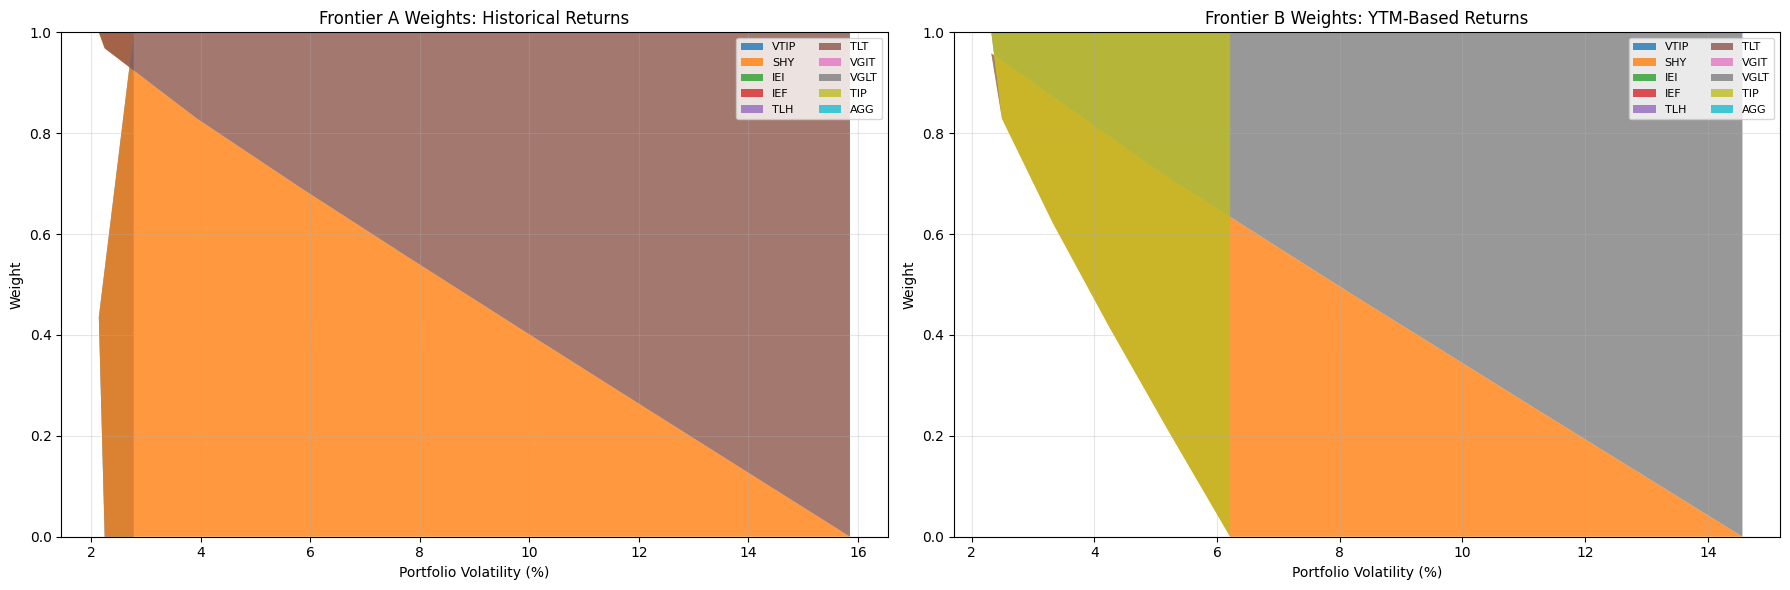

In [32]:
# Show how portfolio weights change across the frontier
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, front, title in [
    (axes[0], front_hist, "Frontier A Weights: Historical Returns"),
    (axes[1], front_ytm,  "Frontier B Weights: YTM-Based Returns"),
]:
    weight_mat = np.array([pt[2] for pt in front])
    vols = np.array([pt[0] for pt in front])
    ax.stackplot(vols, weight_mat.T, labels=etf_list, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel("Portfolio Volatility (%)")
    ax.set_ylabel("Weight")
    ax.legend(loc="upper right", fontsize=8, ncol=2)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Risk Contribution Analysis

**Component risk contribution** measures how much of total portfolio volatility each ETF drives.  
Even if a position is small in weight, if it's highly correlated to the rest of the portfolio, it contributes disproportionately to risk.

For Treasury ETFs, risk contribution tracks closely with **duration exposure** — the dominant risk factor.  
A "barbelled" portfolio (BIL + TLT) may show similar total duration to holding IEF — but the volatility profile differs due to convexity.


AGG Benchmark  (vol=6.06%, dur=6.0yr)
  AGG  : weight=100%  risk contrib=100.0%

Equal Weight  (vol=7.33%, dur=7.3yr)
  VTIP : weight=10%  risk contrib=2.4%
  SHY  : weight=10%  risk contrib=2.1%
  IEI  : weight=10%  risk contrib=6.0%
  IEF  : weight=10%  risk contrib=10.3%
  TLH  : weight=10%  risk contrib=17.0%
  TLT  : weight=10%  risk contrib=20.9%
  VGIT : weight=10%  risk contrib=6.9%
  VGLT : weight=10%  risk contrib=19.3%
  TIP  : weight=10%  risk contrib=7.2%
  AGG  : weight=10%  risk contrib=8.1%

Barbell (BIL+TLT)  (vol=7.93%, dur=8.0yr)
  TLT  : weight=50%  risk contrib=100.0%

Belly Focus (IEF+VGIT)  (vol=6.49%, dur=6.4yr)
  IEF  : weight=50%  risk contrib=59.0%
  VGIT : weight=50%  risk contrib=41.0%


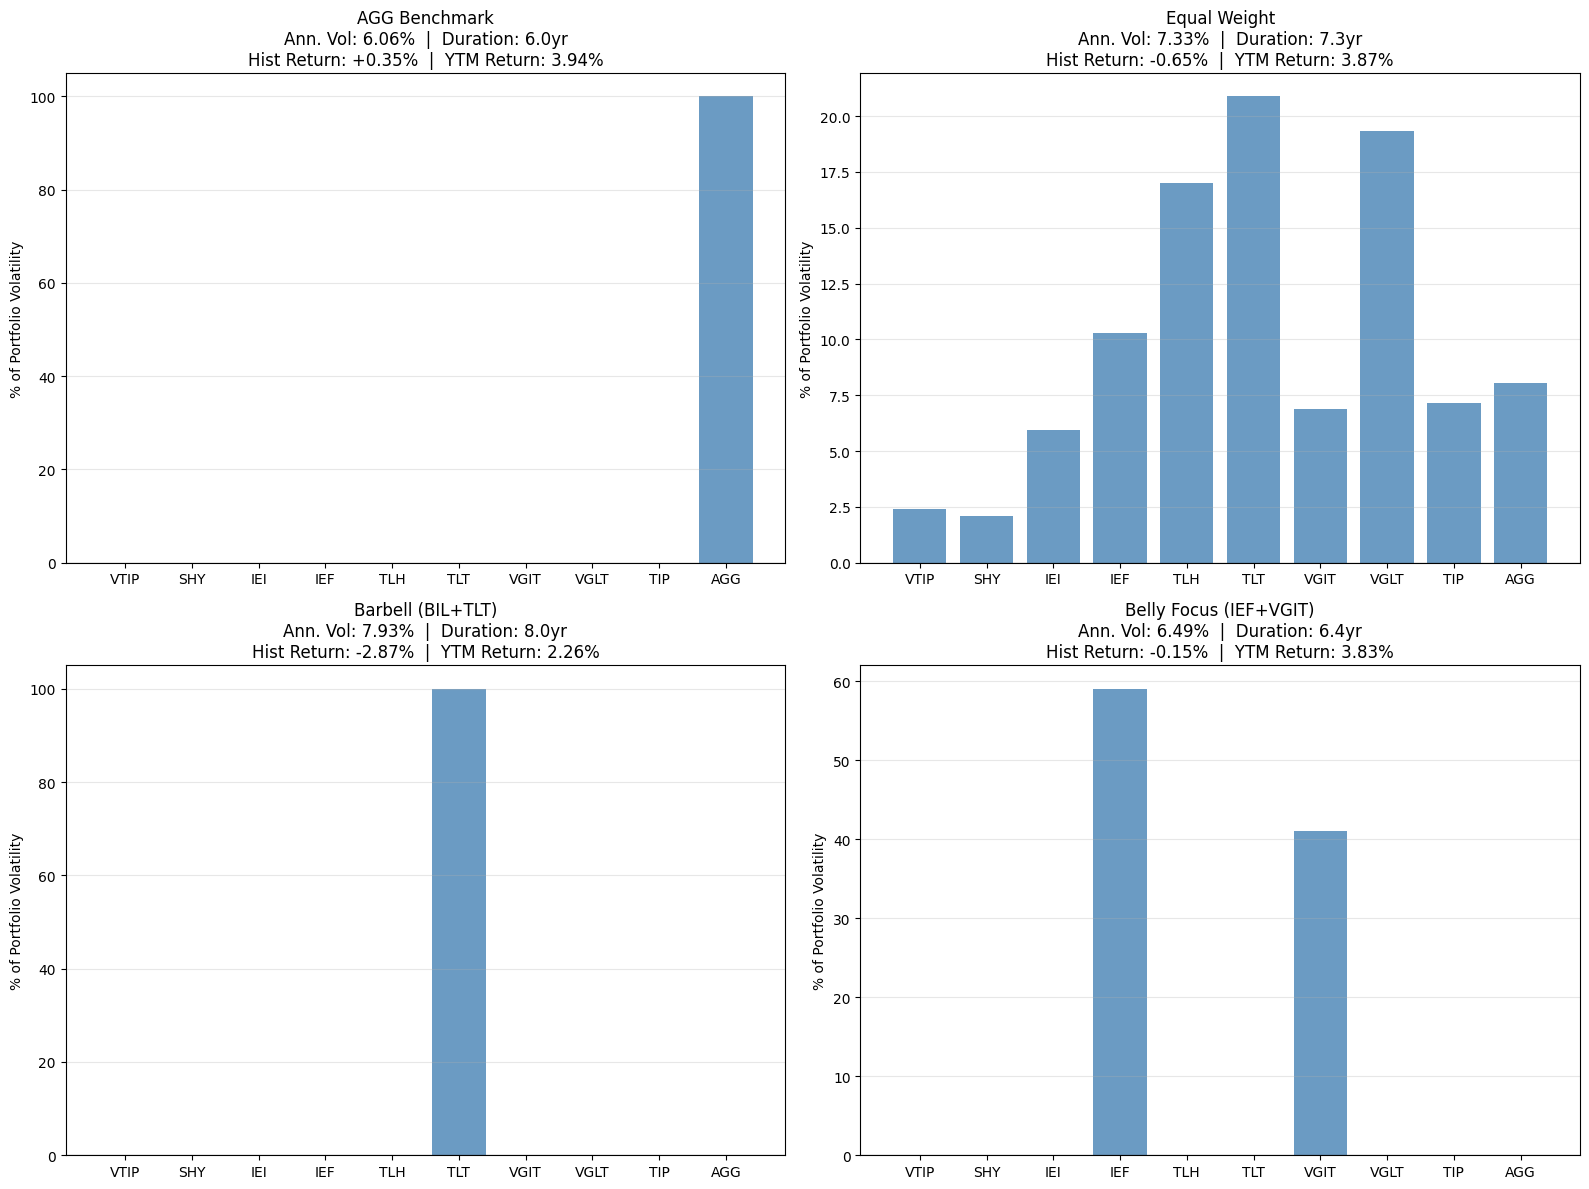

In [33]:
def component_risk_contribution(weights, cov):
    """Marginal and component risk contributions."""
    weights = np.array(weights)
    port_vol = np.sqrt(weights @ cov @ weights)
    marginal_contrib = (cov @ weights) / port_vol
    component_contrib = weights * marginal_contrib
    pct_contrib = component_contrib / port_vol * 100
    return component_contrib, pct_contrib

cov_arr = cov_mat[etf_list].loc[etf_list].values

# Three sample portfolios
portfolios = {
    "AGG Benchmark":    w_bench,
    "Equal Weight":     w_eq,
    "Barbell (BIL+TLT)": np.array([0.5 if tk in ("BIL","TLT") else 0.0 for tk in etf_list]),
    "Belly Focus (IEF+VGIT)": np.array([0.5 if tk in ("IEF","VGIT") else 0.0 for tk in etf_list]),
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (name, w) in enumerate(portfolios.items()):
    comp, pct = component_risk_contribution(w, cov_arr)
    port_ret_hist, port_vol = portfolio_stats(w, mu_hist, cov_arr)
    port_ret_ytm, _         = portfolio_stats(w, mu_ytm, cov_arr)
    port_dur = sum(w[j] * ETF_META[etf_list[j]]["mod_duration"] for j in range(n))
    
    colors = ["steelblue" if pct[j] >= 0 else "red" for j in range(n)]
    bars = axes[i].bar(etf_list, pct, color=colors, alpha=0.8)
    axes[i].set_title(f"{name}\nAnn. Vol: {port_vol*100:.2f}%  |  Duration: {port_dur:.1f}yr\n"
                      f"Hist Return: {port_ret_hist*100:+.2f}%  |  YTM Return: {port_ret_ytm*100:.2f}%")
    axes[i].set_ylabel("% of Portfolio Volatility")
    axes[i].axhline(0, color="black", linewidth=0.8)
    axes[i].grid(True, alpha=0.3, axis="y")
    
    print(f"\n{name}  (vol={port_vol*100:.2f}%, dur={port_dur:.1f}yr)")
    for j, tk in enumerate(etf_list):
        if w[j] > 0:
            print(f"  {tk:5s}: weight={w[j]*100:.0f}%  risk contrib={pct[j]:.1f}%")

plt.tight_layout()
plt.show()

## 8. Dividend Yield Analysis

For bond ETFs, the dividend yield is the **primary return driver** over most holding periods.  
Price appreciation/depreciation can dominate in the short run (rate moves), but over the duration horizon, yield ≈ total return.

Key axes to examine:
- Yield vs. duration: how much extra yield do we get for each year of additional duration?
- Yield vs. volatility: what's the income per unit of mark-to-market risk?
- Dividend history: has yield been stable or volatile? (affected by rates + ETF AUM changes)

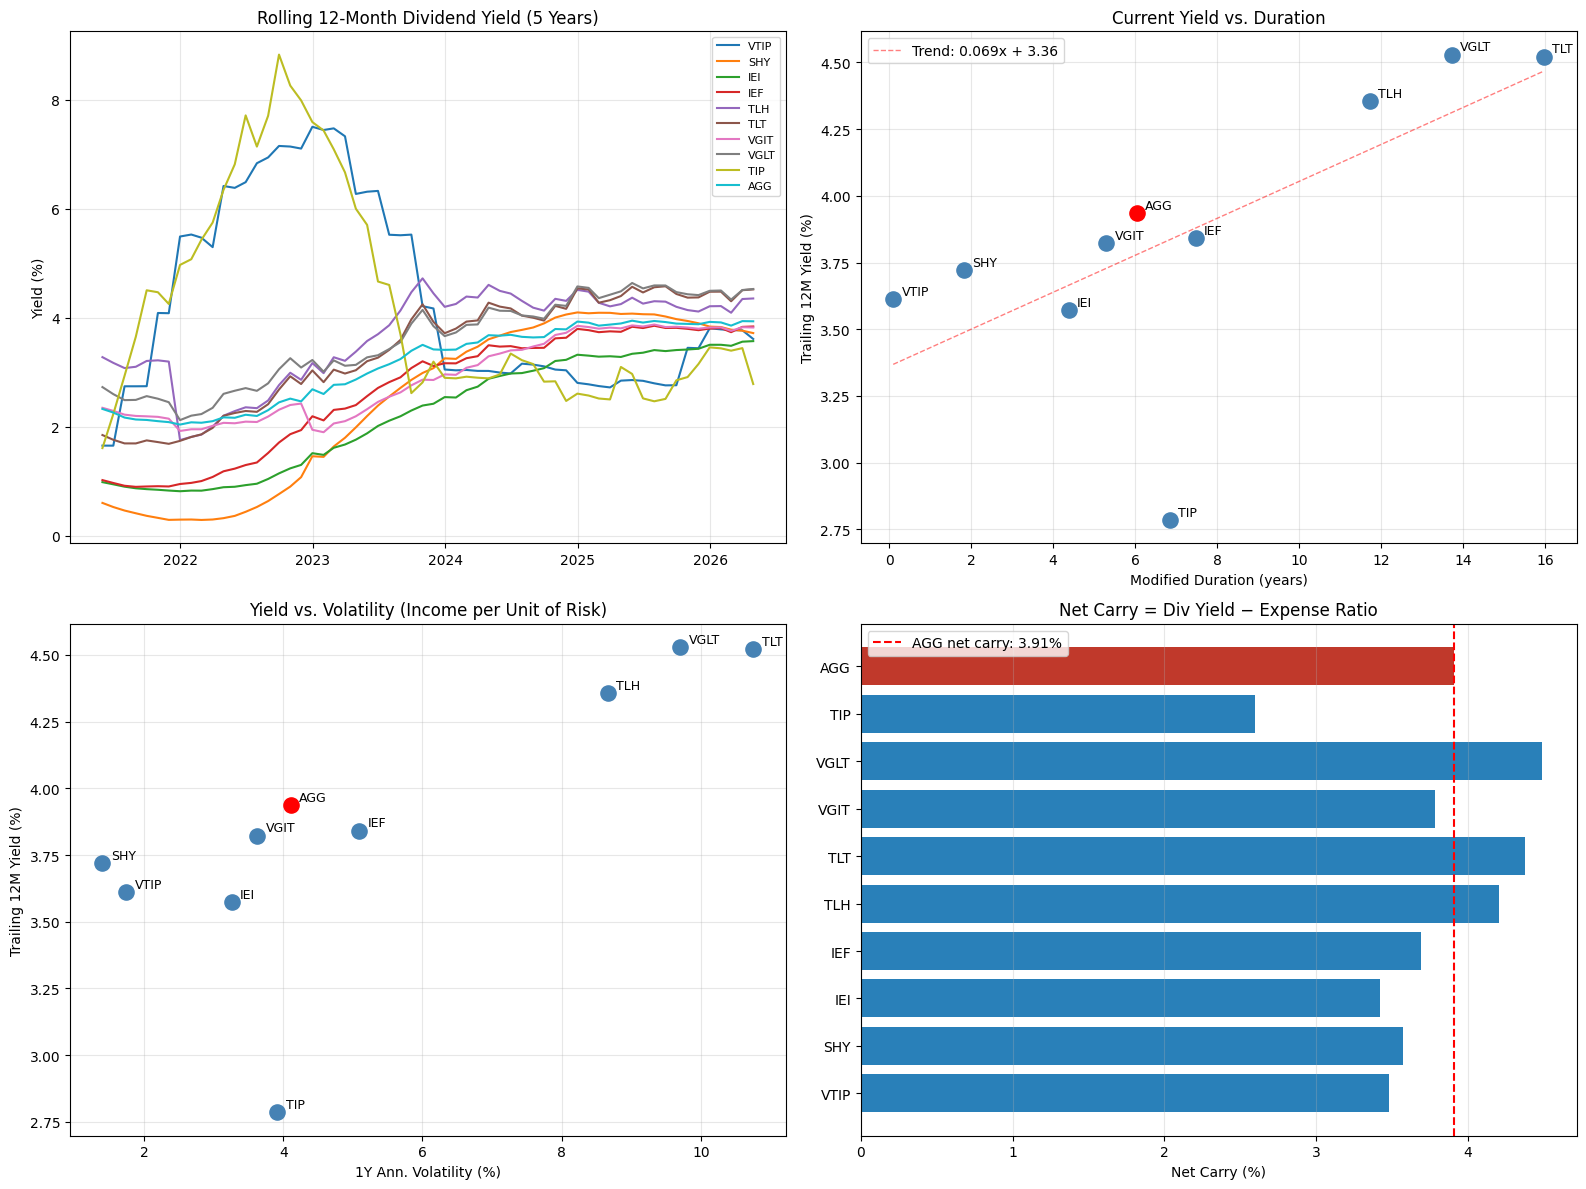


=== Net Carry (Yield - Expense Ratio) ===
  VGLT : 4.489%   (yield 4.53% - exp 0.0400%)
  TLT  : 4.372%   (yield 4.52% - exp 0.1500%)
  TLH  : 4.206%   (yield 4.36% - exp 0.1500%)
  AGG  : 3.907%   (yield 3.94% - exp 0.0300%)
  VGIT : 3.783%   (yield 3.82% - exp 0.0400%)
  IEF  : 3.692%   (yield 3.84% - exp 0.1500%)
  SHY  : 3.570%   (yield 3.72% - exp 0.1500%)
  VTIP : 3.477%   (yield 3.61% - exp 0.1356%)
  IEI  : 3.423%   (yield 3.57% - exp 0.1500%)
  TIP  : 2.595%   (yield 2.79% - exp 0.1900%)


In [34]:
# Monthly dividend yield time series for each ETF
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Rolling 12M yield history
ax = axes[0, 0]
for tk in TICKERS:
    h = raw[tk]
    monthly_div = h["Dividends"].resample("ME").sum()
    monthly_price = h["Close"].resample("ME").last()
    roll_yield = monthly_div.rolling(12).sum() / monthly_price * 100
    ax.plot(roll_yield.index[-60:], roll_yield.iloc[-60:], linewidth=1.5, label=tk)
ax.set_title("Rolling 12-Month Dividend Yield (5 Years)")
ax.set_ylabel("Yield (%)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Current yield vs duration scatter (with trendline)
ax = axes[0, 1]
durs_arr  = np.array([ETF_META[tk]["mod_duration"] for tk in TICKERS])
yields_arr = np.array([raw[tk]["Dividends"].tail(252).sum() / raw[tk]["Close"].iloc[-1] * 100 for tk in TICKERS])
for i, tk in enumerate(TICKERS):
    color = "red" if tk == BENCH else "steelblue"
    ax.scatter(durs_arr[i], yields_arr[i], s=120, color=color, zorder=3)
    ax.annotate(tk, (durs_arr[i], yields_arr[i]), textcoords="offset points", xytext=(6, 3), fontsize=9)
# Trendline
z = np.polyfit(durs_arr, yields_arr, 1)
p = np.poly1d(z)
x_line = np.linspace(durs_arr.min(), durs_arr.max(), 100)
ax.plot(x_line, p(x_line), "r--", alpha=0.5, linewidth=1, label=f"Trend: {z[0]:.3f}x + {z[1]:.2f}")
ax.set_title("Current Yield vs. Duration")
ax.set_xlabel("Modified Duration (years)")
ax.set_ylabel("Trailing 12M Yield (%)")
ax.legend()
ax.grid(True, alpha=0.3)

# Yield vs volatility (income per unit of risk)
ax = axes[1, 0]
vols_arr = np.array([daily_ret[tk].dropna().tail(252).std() * np.sqrt(252) * 100 for tk in TICKERS])
for i, tk in enumerate(TICKERS):
    color = "red" if tk == BENCH else "steelblue"
    ax.scatter(vols_arr[i], yields_arr[i], s=120, color=color, zorder=3)
    ax.annotate(tk, (vols_arr[i], yields_arr[i]), textcoords="offset points", xytext=(6, 3), fontsize=9)
ax.set_title("Yield vs. Volatility (Income per Unit of Risk)")
ax.set_xlabel("1Y Ann. Volatility (%)")
ax.set_ylabel("Trailing 12M Yield (%)")
ax.grid(True, alpha=0.3)

# Yield minus expense ratio (net carry)
ax = axes[1, 1]
net_carry = {tk: yields_arr[i] - ETF_META[tk]["expense_ratio"] for i, tk in enumerate(TICKERS)}
colors = ["#c0392b" if tk == BENCH else "#2980b9" for tk in TICKERS]
ax.barh(TICKERS, list(net_carry.values()), color=colors)
ax.axvline(net_carry[BENCH], color="red", linestyle="--", linewidth=1.5, label=f"AGG net carry: {net_carry[BENCH]:.2f}%")
ax.set_title("Net Carry = Div Yield − Expense Ratio")
ax.set_xlabel("Net Carry (%)")
ax.legend()
ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

print("\n=== Net Carry (Yield - Expense Ratio) ===")
for tk, nc in sorted(net_carry.items(), key=lambda x: -x[1]):
    print(f"  {tk:5s}: {nc:.3f}%   (yield {yields_arr[TICKERS.index(tk)]:.2f}% - exp {ETF_META[tk]['expense_ratio']:.4f}%)")

## 9. Summary: What Would We Own?

*(Fill in at each presentation cycle — connect quant output to qualitative macro view.)*

### What the Model Shows

**Historical frontier:**  
Short-duration ETFs dominate — the 2022 rate shock punishes anything with duration > 5yr.  
This is a backward-looking result and doesn't necessarily predict the forward environment.

**YTM frontier:**  
Higher-duration ETFs look more attractive — their current yield compensates for the risk.  
The belly (IEI/IEF/VGIT) tends to offer the best yield-per-unit-of-duration in a normal curve.

**Cointegration:**  
Treasury ETFs are highly cointegrated — true diversification from mixing them is limited.  
The frontier flatters the benefit of barbelling vs. concentrating in one maturity bucket.

---

### Decision Framework

| Scenario | Preferred ETFs | Rationale |
|----------|---------------|-----------|
| Steep curve, Fed cutting | IEF, VGIT, TLT | Best carry + rolldown; long end benefits from cuts |
| Flat/inverted curve | BIL, SHY | Capture short-end yield with minimal duration risk |
| Stagflation risk | TIP | Real yield + inflation protection |
| Risk-off / recession | TLT, VGLT | Flight to quality; long end rallies fastest |
| Fiscal premium / bear steepener | SHY, BIL | Avoid long end if term premium reprices higher |
| Uncertain / neutral | AGG, VGIT | Balanced duration; AGG adds credit diversification |

---

### Current Call

*Space for current positioning rationale — update each cycle:*

- Duration over/underweight vs. AGG:  
- Key ETF(s) and why:  
- Main risk to the call:  
- What would change the view:

## Excel Export

Writes all key quantitative outputs to `output/etf_frontier.xlsx` via `NotebookWorkbook`.  
Re-run this cell any time to refresh with latest data.

In [35]:
from tools.excel import NotebookWorkbook

OUT_PATH = data.PROJECT_ROOT / "models" / "treasuries_spring26" / "output" / "etf_frontier.xlsx"
wb = NotebookWorkbook(OUT_PATH)

# ── Sheet 1: Risk/Return Statistics (5Y) ───────────────────────────────────
wb.write("Risk Return Stats", df_stats.reset_index())

# ── Sheet 2: Stationarity Tests ───────────────────────────────────────────────
stat_rows_levels = []
stat_rows_returns = []
for tk in TICKERS:
    for label, series in [("Level", log_prices[tk]), ("Return", log_ret[tk])]:
        s = series.dropna()
        adf_stat, adf_p, _, _, _, _ = adfuller(s, autolag="AIC")
        kpss_stat, kpss_p, _, _ = kpss(s, regression="c", nlags="auto")
        row = {
            "Ticker":    tk,
            "Series":    label,
            "ADF_stat":  round(adf_stat, 4),
            "ADF_pval":  round(adf_p, 4),
            "ADF_stationary": adf_p < 0.05,
            "KPSS_stat": round(kpss_stat, 4),
            "KPSS_pval": round(kpss_p, 4),
            "KPSS_stationary": kpss_p > 0.05,
        }
        if label == "Level":
            stat_rows_levels.append(row)
        else:
            stat_rows_returns.append(row)
wb.write("Stationarity - Levels",  pd.DataFrame(stat_rows_levels))
wb.write("Stationarity - Returns", pd.DataFrame(stat_rows_returns))

# ── Sheet 4: Johansen Test ───────────────────────────────────────────────────────
johansen_rows = []
for i in range(min(len(result.lr1), len(TICKERS))):
    johansen_rows.append({
        "r_leq":      i,
        "Trace_Stat": round(result.lr1[i], 3),
        "CV_5pct":    round(result.cvt[i, 1], 3),
        "CV_1pct":    round(result.cvt[i, 0], 3),
        "Reject_5pct": result.lr1[i] > result.cvt[i, 1],
    })
wb.write("Cointegration EG",  coint_matrix.reset_index())
wb.write("Cointegration Johansen", pd.DataFrame(johansen_rows))

# ── Sheet 6: Duration and Convexity ───────────────────────────────────────────
df_meta = pd.DataFrame([{"Ticker": tk, **ETF_META[tk]} for tk in TICKERS])
wb.write("Duration Convexity", df_meta)

# ── Sheet 7: Price Sensitivity Table ──────────────────────────────────────────
shock_grid = [-300, -200, -150, -100, -75, -50, -25, 0, 25, 50, 75, 100, 150, 200, 300]
psens_rows = []
for s_bps in shock_grid:
    row = {"Shock_bps": s_bps}
    for tk in TICKERS:
        d = ETF_META[tk]["mod_duration"]
        c = ETF_META[tk]["convexity"]
        row[tk] = round((-d*(s_bps/100) + 0.5*c*(s_bps/100)**2)*100, 3)
    psens_rows.append(row)
wb.write("Price Sensitivity", pd.DataFrame(psens_rows))

# ── Sheet 8: Correlation Matrix ───────────────────────────────────────────────────
wb.write("Correlations", corr.reset_index())

# ── Sheet 9: Rolling 1Y Correlation vs AGG ───────────────────────────────────
roll_corr_dict = {}
for tk in [t for t in TICKERS if t != BENCH]:
    roll_corr_dict[tk] = ret_common[tk].rolling(252).corr(ret_common[BENCH])
df_roll_corr = pd.DataFrame(roll_corr_dict)
df_roll_corr.index.name = "Date"
wb.write("Rolling Corr vs AGG", df_roll_corr.reset_index())

# ── Sheet 10: Rolling Sharpe (1Y) ───────────────────────────────────────────────
roll_ann_ret = daily_ret.rolling(252).apply(lambda x: (1+x).prod()**(252/252) - 1, raw=False)
roll_vol_252 = daily_ret.rolling(252).std() * np.sqrt(252)
roll_sharpe  = roll_ann_ret / roll_vol_252
df_roll_sharpe = roll_sharpe.copy()
df_roll_sharpe.index.name = "Date"
wb.write("Rolling Sharpe 1Y",  df_roll_sharpe.reset_index())
wb.write("Rolling Vol 1Y",     (roll_vol_252 * 100).rename_axis("Date").reset_index())

# ── Sheet 12: Efficient Frontier ────────────────────────────────────────────────
df_front_hist = pd.DataFrame([(v, r) for v, r, _ in front_hist], columns=["Vol_pct", "Return_pct"])
df_front_ytm  = pd.DataFrame([(v, r) for v, r, _ in front_ytm],  columns=["Vol_pct", "Expected_Return_pct"])
wb.write("Frontier Historical", df_front_hist)
wb.write("Frontier YTM",        df_front_ytm)

# ── Sheet 14: Frontier Weights (full, not subsampled) ────────────────────────────
df_w_hist = pd.DataFrame([pt[2] for pt in front_hist], columns=etf_list)
df_w_hist.insert(0, "Vol_pct", [pt[0] for pt in front_hist])
df_w_hist.insert(1, "Return_pct", [pt[1] for pt in front_hist])
df_w_ytm = pd.DataFrame([pt[2] for pt in front_ytm], columns=etf_list)
df_w_ytm.insert(0, "Vol_pct", [pt[0] for pt in front_ytm])
df_w_ytm.insert(1, "Expected_Return_pct", [pt[1] for pt in front_ytm])
wb.write("Weights Historical", df_w_hist)
wb.write("Weights YTM",        df_w_ytm)

# ── Sheet 16: Individual ETF coordinates on frontier ────────────────────────────
etf_coords = []
for i, tk in enumerate(etf_list):
    w = np.eye(n)[i]
    r_hist, v = portfolio_stats(w, mu_hist, cov_mat.values)
    r_ytm,  _ = portfolio_stats(w, mu_ytm,  cov_mat.values)
    etf_coords.append({
        "Ticker":          tk,
        "Vol_pct":         round(v*100, 3),
        "Hist_Return_pct": round(r_hist*100, 3),
        "YTM_Return_pct":  round(r_ytm*100, 3),
        "Mod_Duration":    ETF_META[tk]["mod_duration"],
    })
wb.write("ETF Frontier Points", pd.DataFrame(etf_coords))

# ── Sheet 17: Risk Contributions for sample portfolios ───────────────────────────
risk_contrib_rows = []
for pname, w in portfolios.items():
    comp, pct = component_risk_contribution(w, cov_arr)
    port_ret_h, port_vol = portfolio_stats(w, mu_hist, cov_arr)
    port_ret_y, _        = portfolio_stats(w, mu_ytm,  cov_arr)
    port_dur = sum(w[j] * ETF_META[etf_list[j]]["mod_duration"] for j in range(n))
    for j, tk in enumerate(etf_list):
        risk_contrib_rows.append({
            "Portfolio":         pname,
            "Ticker":            tk,
            "Weight":            round(w[j], 4),
            "Comp_Risk_Contrib": round(comp[j], 6),
            "Pct_Risk_Contrib":  round(pct[j], 3),
            "Port_Vol_pct":      round(port_vol*100, 3),
            "Port_Duration":     round(port_dur, 2),
            "Hist_Return_pct":   round(port_ret_h*100, 3),
            "YTM_Return_pct":    round(port_ret_y*100, 3),
        })
wb.write("Risk Contributions", pd.DataFrame(risk_contrib_rows))

# ── Sheet 18: Dividend Yield History (rolling 12M monthly, 5Y) ───────────────────
div_yield_hist = {}
for tk in TICKERS:
    h = raw[tk]
    monthly_div   = h["Dividends"].resample("ME").sum()
    monthly_price = h["Close"].resample("ME").last()
    roll_yield    = monthly_div.rolling(12).sum() / monthly_price * 100
    div_yield_hist[tk] = roll_yield
df_div_hist = pd.DataFrame(div_yield_hist)
df_div_hist.index.name = "Date"
wb.write("Dividend Yield History", df_div_hist.reset_index())

# ── Sheet 19: Net Carry (yield − expense ratio) ───────────────────────────────────
yields_arr = np.array([raw[tk]["Dividends"].tail(252).sum() / raw[tk]["Close"].iloc[-1] * 100 for tk in TICKERS])
net_carry_rows = [
    {
        "Ticker":        tk,
        "Div_Yield_pct": round(yields_arr[i], 3),
        "Expense_Ratio": ETF_META[tk]["expense_ratio"],
        "Net_Carry_pct": round(yields_arr[i] - ETF_META[tk]["expense_ratio"], 3),
        "Mod_Duration":  ETF_META[tk]["mod_duration"],
    }
    for i, tk in enumerate(TICKERS)
]
wb.write("Net Carry", pd.DataFrame(net_carry_rows))

# ── Sheet 20: Prices 5Y ───────────────────────────────────────────────────────────────
wb.write("Prices 5Y", prices.tail(252*5).reset_index().rename(columns={"index": "Date"}))

path = wb.save()
print(f"Saved → {path}")
import openpyxl
print(f"Sheets ({len(openpyxl.load_workbook(path).sheetnames)}): {openpyxl.load_workbook(path).sheetnames}")


Saved → C:\Users\btm74.000\Projects\qf_toolset\models\treasuries_spring26\output\etf_frontier.xlsx
Sheets (20): ['Risk Return Stats', 'Stationarity - Levels', 'Stationarity - Returns', 'Cointegration EG', 'Cointegration Johansen', 'Duration Convexity', 'Price Sensitivity', 'Correlations', 'Rolling Corr vs AGG', 'Rolling Sharpe 1Y', 'Rolling Vol 1Y', 'Frontier Historical', 'Frontier YTM', 'Weights Historical', 'Weights YTM', 'ETF Frontier Points', 'Risk Contributions', 'Dividend Yield History', 'Net Carry', 'Prices 5Y']
